In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("miadul/brain-tumor-dataset")

print("Path to dataset files:", path)

100%|██████████| 852k/852k [00:00<00:00, 1.00MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/miadul/brain-tumor-dataset/versions/1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score





df = pd.read_csv("/root/.cache/kagglehub/datasets/miadul/brain-tumor-dataset/versions/1/brain_tumor_dataset.csv")
df.head()

,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,1,73,Male,Malignant,5.375612,Temporal,Astrocytoma,III,Vision Issues,Seizures,Seizures,No,No,No,51.312579,0.111876,No,Positive,Yes
1,2,26,Male,Benign,4.847098,Parietal,Glioblastoma,II,Headache,Headache,Nausea,Yes,Yes,Yes,46.373273,2.165736,Yes,Positive,Yes
2,3,31,Male,Benign,5.588391,Parietal,Meningioma,I,Vision Issues,Headache,Seizures,No,No,No,47.072221,1.884228,No,Negative,No
3,4,29,Male,Malignant,1.436600,Temporal,Medulloblastoma,IV,Vision Issues,Seizures,Headache,Yes,No,Yes,51.853634,1.283342,Yes,Negative,No
4,5,54,Female,Benign,2.417506,Parietal,Glioblastoma,I,Headache,Headache,Seizures,No,No,Yes,54.708987,2.069477,No,Positive,Yes


## EDA

In [3]:
df.describe()

,Patient_ID,Age,Tumor_Size,Survival_Rate,Tumor_Growth_Rate
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,49.433700,5.236552,70.131699,1.547701
std,5773.647028,17.389296,2.754359,17.270834,0.835995
min,1.000000,20.000000,0.500410,40.002386,0.100017
25%,5000.750000,34.000000,2.836686,55.224439,0.830433
50%,10000.500000,49.000000,5.200675,70.305066,1.541821
75%,15000.250000,65.000000,7.624299,85.043395,2.262484
max,20000.000000,79.000000,9.999420,99.998125,2.999835


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           20000 non-null  int64  
 1   Age                  20000 non-null  int64  
 2   Gender               20000 non-null  object 
 3   Tumor_Type           20000 non-null  object 
 4   Tumor_Size           20000 non-null  float64
 5   Location             20000 non-null  object 
 6   Histology            20000 non-null  object 
 7   Stage                20000 non-null  object 
 8   Symptom_1            20000 non-null  object 
 9   Symptom_2            20000 non-null  object 
 10  Symptom_3            20000 non-null  object 
 11  Radiation_Treatment  20000 non-null  object 
 12  Surgery_Performed    20000 non-null  object 
 13  Chemotherapy         20000 non-null  object 
 14  Survival_Rate        20000 non-null  float64
 15  Tumor_Growth_Rate    20000 non-null 

In [5]:
for column in df.select_dtypes(include='object').columns:
    print(f"Column '{column}': {df[column].nunique()} unique values")

Column 'Gender': 2 unique values
Column 'Tumor_Type': 2 unique values
Column 'Location': 4 unique values
Column 'Histology': 4 unique values
Column 'Stage': 4 unique values
Column 'Symptom_1': 4 unique values
Column 'Symptom_2': 4 unique values
Column 'Symptom_3': 4 unique values
Column 'Radiation_Treatment': 2 unique values
Column 'Surgery_Performed': 2 unique values
Column 'Chemotherapy': 2 unique values
Column 'Family_History': 2 unique values
Column 'MRI_Result': 2 unique values
Column 'Follow_Up_Required': 2 unique values


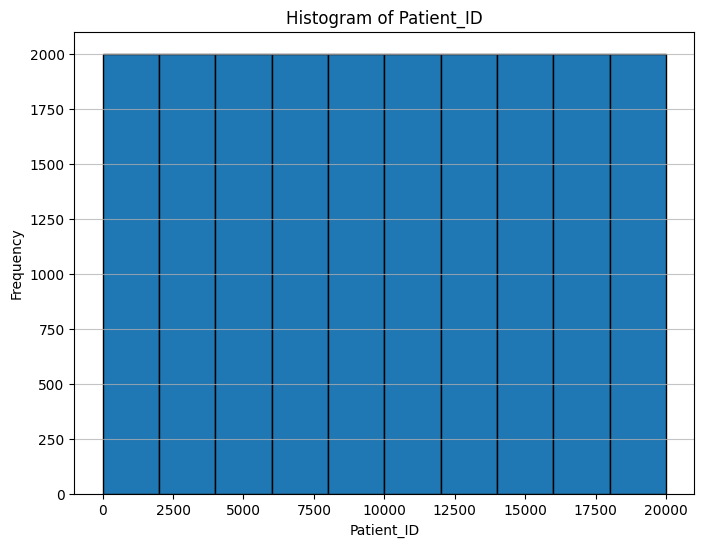

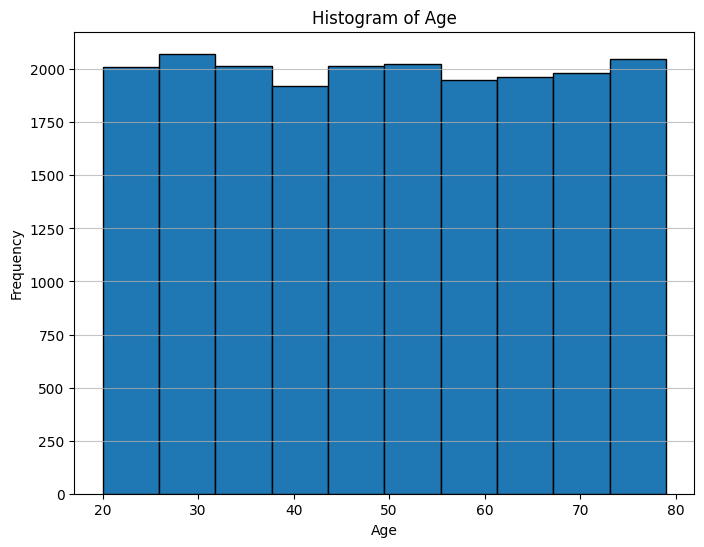

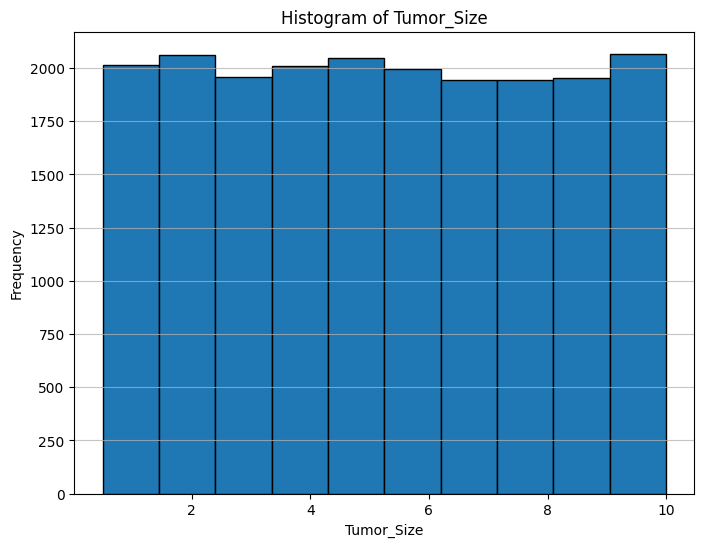

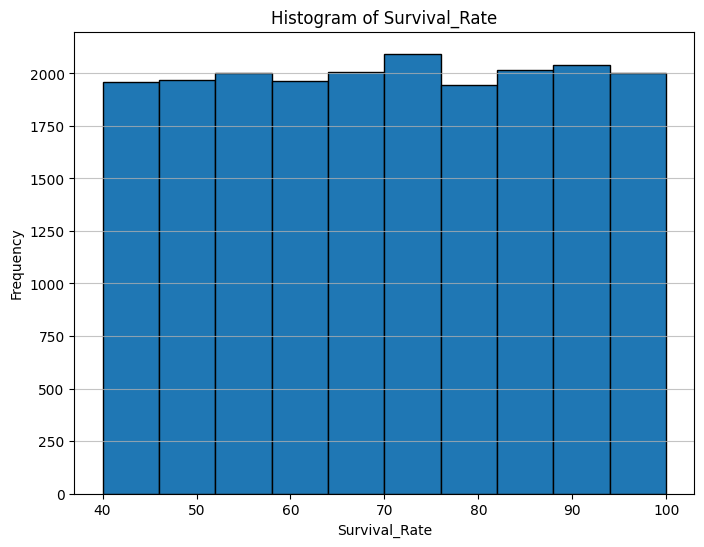

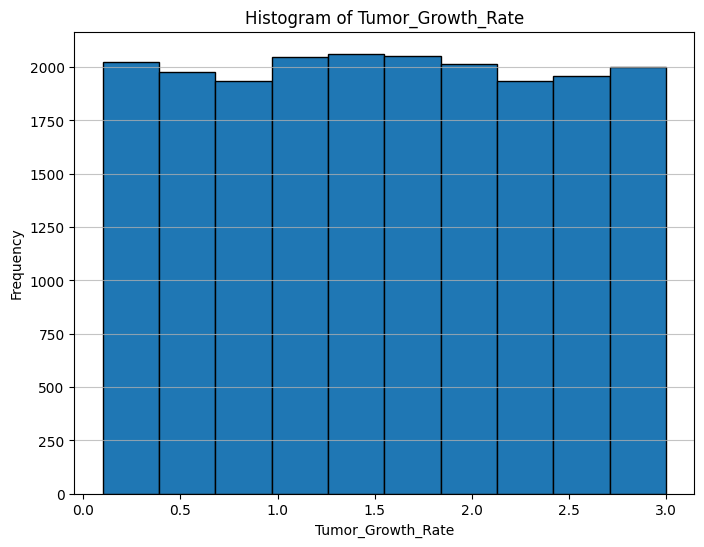

In [6]:
import matplotlib.pyplot as plt

# Identify numerical columns (excluding potential ID columns if any)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    plt.hist(df[col], bins=10, edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Histogram of {col}')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

In [7]:
import pandas as pd

# Identify categorical columns (including boolean-like columns represented as objects)
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nProportions for column '{col}':")
    proportions = df[col].value_counts(normalize=True) * 100
    print(proportions.round(2).astype(str) + '%')


Proportions for column 'Gender':
Gender
Female    50.08%
Male      49.92%
Name: proportion, dtype: object

Proportions for column 'Tumor_Type':
Tumor_Type
Malignant    50.15%
Benign       49.85%
Name: proportion, dtype: object

Proportions for column 'Location':
Location
Temporal     25.59%
Parietal     24.95%
Occipital    24.83%
Frontal      24.62%
Name: proportion, dtype: object

Proportions for column 'Histology':
Histology
Glioblastoma       25.34%
Meningioma         25.08%
Medulloblastoma     24.9%
Astrocytoma        24.68%
Name: proportion, dtype: object

Proportions for column 'Stage':
Stage
II     25.46%
I      24.93%
IV     24.84%
III    24.76%
Name: proportion, dtype: object

Proportions for column 'Symptom_1':
Symptom_1
Headache         25.22%
Seizures         25.14%
Nausea           24.84%
Vision Issues    24.79%
Name: proportion, dtype: object

Proportions for column 'Symptom_2':
Symptom_2
Seizures         25.27%
Vision Issues     25.1%
Headache         24.98%
Nausea     

In [8]:
import numpy as np
from scipy.stats import chisquare

# Define the Age column data
age_data = df['Age']

# Determine the range of ages to create bins
min_age = age_data.min()
max_age = age_data.max()

# Choose a number of bins for the chi-squared test
# A common rule of thumb is sqrt(N) or similar. Let's use 10 bins for this range.
num_bins = 10

# Create bins and count observed frequencies
# The `hist` function returns counts and bin edges
observed_frequencies, bin_edges = np.histogram(age_data, bins=num_bins, range=(min_age, max_age))

# Calculate expected frequencies for a uniform distribution
# If uniform, each bin should have approximately the same count
total_observations = len(age_data)
expected_frequencies = np.full(num_bins, total_observations / num_bins)

print(f"Observed Frequencies: {observed_frequencies}")
print(f"Expected Frequencies: {expected_frequencies}")

# Perform the chi-squared goodness-of-fit test
# The test compares observed frequencies to expected frequencies.
# If any expected frequency is zero, chisquare will raise an error,
# so we might need to adjust bins or handle this case.
# Given a large dataset (20000), this is unlikely with reasonable binning.
chi2_statistic, p_value = chisquare(f_obs=observed_frequencies, f_exp=expected_frequencies)

print(f"\nChi-squared Statistic: {chi2_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
alpha = 0.05 # Significance level
if p_value < alpha:
    print(f"Based on the p-value ({p_value:.4f} < {alpha}), we reject the null hypothesis.")
    print("This suggests that the age distribution is NOT uniform.")
else:
    print(f"Based on the p-value ({p_value:.4f} >= {alpha}), we fail to reject the null hypothesis.")
    print("This suggests that there is no significant evidence to conclude that the age distribution is not uniform (i.e., it could be uniform).")

Observed Frequencies: [2010 2073 2013 1921 2017 2023 1948 1963 1984 2048]
Expected Frequencies: [2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.]

Chi-squared Statistic: 9.6450
P-value: 0.3800
Based on the p-value (0.3800 >= 0.05), we fail to reject the null hypothesis.
This suggests that there is no significant evidence to conclude that the age distribution is not uniform (i.e., it could be uniform).


In [9]:
combined_treatment_patients = df[
    (df['Radiation_Treatment'] == 'Yes') &
    (df['Surgery_Performed'] == 'Yes') &
    (df['Chemotherapy'] == 'Yes')
].shape[0]

print(f"Number of patients who received Radiation Treatment, Surgery, AND Chemotherapy: {combined_treatment_patients}")

Number of patients who received Radiation Treatment, Surgery, AND Chemotherapy: 2590


## Decidimos la variable objetivo (Tumor_Type) y hacemos EDA sobre el caso Malignant

In [10]:
y = df['Tumor_Type']
X = df.drop('Tumor_Type', axis=1)

In [11]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Update y to be the encoded version for subsequent steps
y = y_encoded

print("Original Tumor Type classes:", label_encoder.classes_)
print("Encoded Tumor Type labels (0 for Benign, 1 for Malignant if sorted alphabetically):", np.unique(y))


Original Tumor Type classes: ['Benign' 'Malignant']
Encoded Tumor Type labels (0 for Benign, 1 for Malignant if sorted alphabetically): [0 1]


In [12]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Tumor_Type', 'Tumor_Size', 'Location',
       'Histology', 'Stage', 'Symptom_1', 'Symptom_2', 'Symptom_3',
       'Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy',
       'Survival_Rate', 'Tumor_Growth_Rate', 'Family_History', 'MRI_Result',
       'Follow_Up_Required'],
      dtype='object')

In [15]:
num_cols = [
       'Age',   'Tumor_Size',
       'Survival_Rate', 'Tumor_Growth_Rate'
          ]

cat_cols = [
    'Gender', 'Location', 'Histology',
    'Symptom_1', 'Symptom_2', 'Symptom_3',
    'Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy',
    'Family_History', 'MRI_Result', 'Follow_Up_Required'
            ]

ord_cols = ['Stage']


print("Variable objetivo (y):", "Encoded Tumor Type")
print("Características numéricas en X:", num_cols)
print("Características categóricas en X:", cat_cols)
print("Características categóricas ordinales en X:", ord_cols)

Variable objetivo (y): Encoded Tumor Type
Características numéricas en X: ['Age', 'Tumor_Size', 'Survival_Rate', 'Tumor_Growth_Rate']
Características categóricas en X: ['Gender', 'Location', 'Histology', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy', 'Family_History', 'MRI_Result', 'Follow_Up_Required']
Características categóricas ordinales en X: ['Stage']


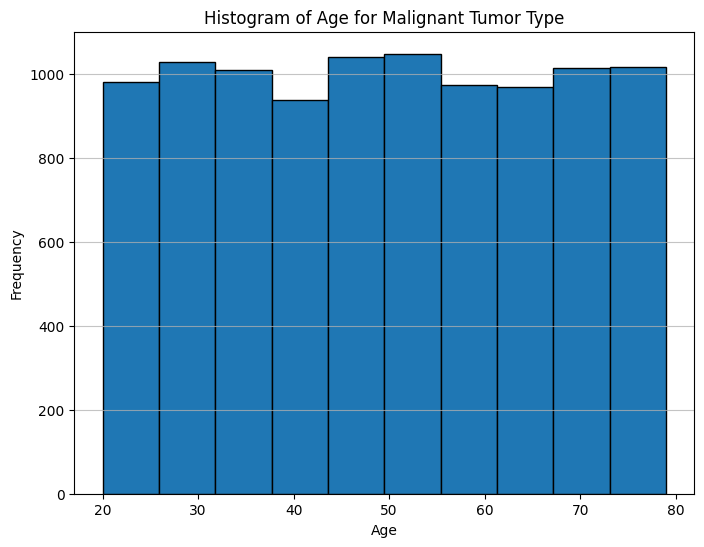

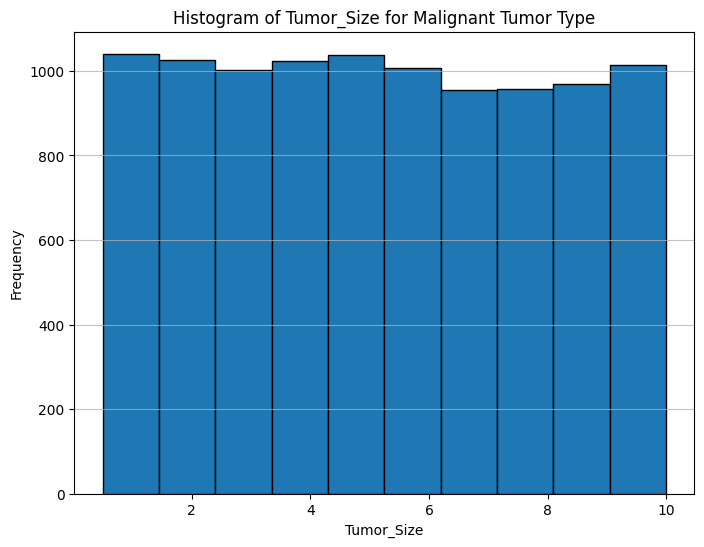

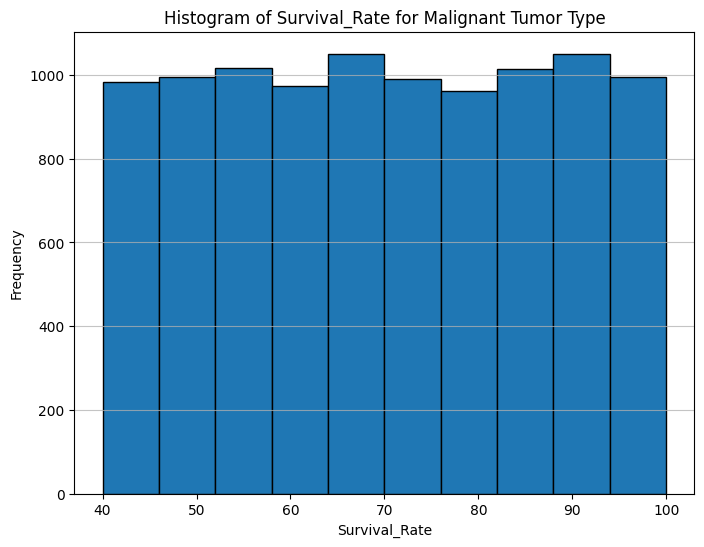

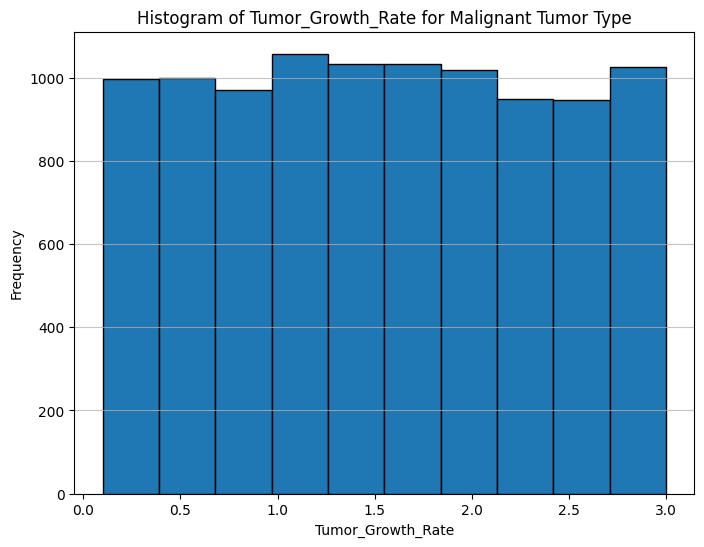

In [16]:
import matplotlib.pyplot as plt

# Filter the DataFrame for 'Malignant' tumor type
df_malignant = df[df['Tumor_Type'] == 'Malignant']

# Identify numerical columns (excluding potential ID columns if any)
numerical_cols = df_malignant.select_dtypes(include=['int64', 'float64']).columns

# Exclude 'Patient_ID' from numerical columns if it's there and not relevant for histogram
if 'Patient_ID' in numerical_cols:
    numerical_cols = numerical_cols.drop('Patient_ID')

for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    plt.hist(df_malignant[col], bins=10, edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Histogram of {col} for Malignant Tumor Type')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

In [17]:

# df_malignant is already defined from the previous step

# Identify categorical columns (including boolean-like columns represented as objects)
categorical_cols = df_malignant.select_dtypes(include='object').columns

# Exclude 'Patient_ID' and 'Tumor_Type' from categorical columns if they are present
categorical_cols = [col for col in categorical_cols if col not in ['Patient_ID', 'Tumor_Type']]

for col in categorical_cols:
    print(f"\nProportions for column '{col}' (Malignant Tumor Type):")
    proportions = df_malignant[col].value_counts(normalize=True) * 100
    print(proportions.round(2).astype(str) + '%')


Proportions for column 'Gender' (Malignant Tumor Type):
Gender
Female    50.27%
Male      49.73%
Name: proportion, dtype: object

Proportions for column 'Location' (Malignant Tumor Type):
Location
Temporal      26.2%
Parietal     24.99%
Occipital    24.42%
Frontal       24.4%
Name: proportion, dtype: object

Proportions for column 'Histology' (Malignant Tumor Type):
Histology
Glioblastoma       25.31%
Meningioma         25.28%
Medulloblastoma    24.73%
Astrocytoma        24.68%
Name: proportion, dtype: object

Proportions for column 'Stage' (Malignant Tumor Type):
Stage
I      25.34%
II     25.23%
III    25.05%
IV     24.37%
Name: proportion, dtype: object

Proportions for column 'Symptom_1' (Malignant Tumor Type):
Symptom_1
Headache         25.13%
Nausea           25.07%
Vision Issues    24.92%
Seizures         24.88%
Name: proportion, dtype: object

Proportions for column 'Symptom_2' (Malignant Tumor Type):
Symptom_2
Vision Issues    25.75%
Seizures         25.18%
Headache         2

### Encodificamos las variables categóricas, booleanas y escalamos las numéricas

In [27]:
model = SVC(kernel='linear', C=1.0)

In [28]:
categories = ["I", "II", "III", "IV"]
ord_transformer = OrdinalEncoder(categories=[categories])
cat_transformer = OneHotEncoder(drop='first')
num_transformer = StandardScaler()

# Creamos preprocesor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols),
        ('ord', ord_transformer, ord_cols)
    ])
pipeline = Pipeline(
    steps=[('preprocessor', preprocessor),
           ('classifier', model)])
pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Tumor_Size',
                                                   'Survival_Rate',
                                                   'Tumor_Growth_Rate']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Gender', 'Location',
                                                   'Histology', 'Symptom_1',
                                                   'Symptom_2', 'Symptom_3',
                                                   'Radiation_Treatment',
                                                   'Surgery_Performed',
                                                   'Chemotherapy',
                                                   'Family_History',
                                                   'MRI_Result',
                                                   'Follow_Up_Required']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['I',
                                                                              'II',
                                                                              'III',
                                                                              'IV']]),
                                                  ['Stage'])])),
                ('classifier', SVC(kernel='linear'))])

In [29]:
pipeline.score(X, y)

0.517

In [30]:
cv_scores = cross_val_score(pipeline, X, y, scoring='f1', cv=5)

In [31]:
mean = np.mean(cv_scores)
mean

np.float64(0.4956605197190672)

## Optimización bayesiana.

In [34]:
!pip install scikit-optimize
from skopt import BayesSearchCV
from skopt.space import Real

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.3 MB/s eta 0:00:00


In [ ]:
# Espacio de búsqueda para C
search_space = {'classifier__C': Real(1e-3, 1e3, prior='log-uniform')}

bayes_search = BayesSearchCV(
    pipeline,          # tu pipeline ya definido
    search_space,
    n_iter=10,         # número de evaluaciones
    scoring='f1',
    cv=5,
    n_jobs=-1,
    random_state=42
)

bayes_search.fit(X, y)

print("Mejor C:", bayes_search.best_params_)
print("Mejor F1 promedio:", bayes_search.best_score_)